# 3.5.1 SASRec 自注意力序列推荐

> 阅读版与 Web 应用内容一致；实验数值来自本 Notebook 的已执行输出。

## Goal

如何用因果自注意力同时建模近期转移与较长兴趣，并预测用户下一部可能喜欢的电影？

## Setup

默认 `smoke` 档使用仓库内固定版本的 GroupLens **MovieLens latest-small** 真实行为子集，CPU 可重复执行；`full` 档只扩大真实数据规模与训练配置，不切换到合成数据。数据包含真实匿名用户、电影、评分和时间戳；实验只做确定性截取与任务重构，不随机制造交互、标签或行为序列。原始许可与引用保存在 `data/ml-latest-small/README.txt`。

**主要资料：** [Kang & McAuley, 2018, SASRec](https://arxiv.org/abs/1808.09781) · [作者官方实现](https://github.com/kang205/SASRec)

In [1]:
from pathlib import Path
import os, sys, json
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
os.environ.setdefault("RECSYS_PROFILE", "smoke")
PROFILE = os.environ["RECSYS_PROFILE"]
from recsys_lab.data import load_movielens, movielens_provenance
real_ratings, real_movies = load_movielens()
REAL_DATASET = movielens_provenance(real_ratings)
print({"profile": PROFILE, "root": str(ROOT), "real_dataset": REAL_DATASET})
assert REAL_DATASET["randomly_fabricated_rows"] == 0

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'profile': 'smoke', 'root': '/workspace', 'real_dataset': {'dataset': 'MovieLens latest-small (GroupLens, generated 2018-09-26)', 'source': 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip', 'license_file': '/workspace/data/ml-latest-small/README.txt', 'rows_used': 26732, 'users_used': 120, 'items_used': 600, 'time_min_utc': '1996-10-17T11:51:49+00:00', 'time_max_utc': '2018-09-13T21:38:16+00:00', 'positive_rule': 'like := observed rating >= 4.0; very_like := observed rating >= 4.5', 'randomly_fabricated_rows': 0}}


## 学习地图

1. 从原始论文理解系统约束；
2. 用可手算数字读懂公式和形状；
3. 检查数据、切分与标签；
4. 使用工业框架模型类训练；
5. 分开验证训练、推理和测试；
6. 用实际输出讨论失败边界。

**本节问题：** 如何用因果自注意力同时建模近期转移与较长兴趣，并预测用户下一部可能喜欢的电影？

**先修知识：** 3.0 的向量、概率与损失函数。第一次阅读无需推导梯度，只要能解释输入、输出和形状。

## Paper & Context

SASRec 用单向 Transformer 编码按时间排列的行为，并在每个位置预测下一物品。它在稀疏数据上可以聚焦少数近期行为，在较密数据上也能利用更长依赖；相对 RNN，训练可并行，但注意力成本随序列长度平方增长。

**来源：** [Kang & McAuley, 2018, SASRec](https://arxiv.org/abs/1808.09781) · [作者官方实现](https://github.com/kang205/SASRec)

请区分三层证据：论文中的离线实验、本 Notebook 验证的代码链路、生产系统尚需验证的在线收益。三者不能互相替代。

## Math by Hand

把 item embedding 与位置 embedding 相加得到 $X$。单头注意力为 $\mathrm{softmax}(QK^\top/\sqrt d)V$，其中因果 mask 把未来位置设为 $-\infty$。位置 $t$ 的表示只能读取 $i_1,\ldots,i_t$，再与正/负物品向量做点积并优化 pairwise logistic loss。

下面用 NumPy/Matplotlib 验证直觉。二维图只是教学投影，工业 embedding 虽有更多维，计算规则相同。

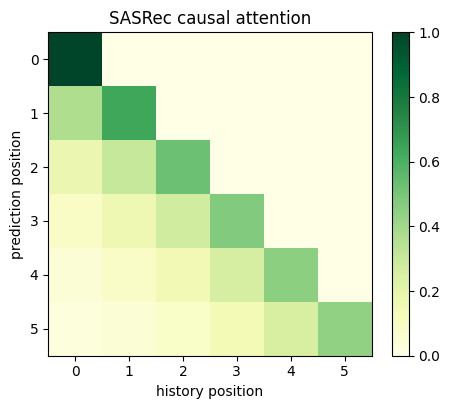

row sums = [1. 1. 1. 1. 1. 1.]


In [2]:
import numpy as np, matplotlib.pyplot as plt
length=6
logits=np.fromfunction(lambda row,col: 2.0-np.abs(row-col)*.55,(length,length))
logits[np.triu(np.ones((length,length),dtype=bool),1)]=-np.inf
weights=np.exp(logits-np.max(logits,axis=1,keepdims=True)); weights/=weights.sum(1,keepdims=True)
fig,ax=plt.subplots(figsize=(5.4,4.2)); image=ax.imshow(weights,cmap='YlGn'); ax.set(title='SASRec causal attention',xlabel='history position',ylabel='prediction position'); plt.colorbar(image,ax=ax); plt.show()
print('row sums =',weights.sum(1).round(3))

## Data

MovieLens latest-small 的真实高评分电影序列。每位用户按 timestamp 排序，倒数一项测试；负序列来自数据中真实低评分电影。

**防泄漏清单：**按时间切分；词表只由训练期建立；负样本来自已观察低评分；序列只看预测时刻以前；测试集只在最后评价。CPU 档使用真实数据的确定性子集，**不是统一 benchmark 成绩**。

## Model & Framework

实际使用 torch_rechub.models.matching.SASRec，包含 item/position embedding、causal multi-head attention 与 pairwise loss；线上可分离用户表示和 item 向量。

smoke 档强调模型类、张量契约和指标链路真实可运行；full 档应替换原始数据、分布式配置、索引/服务和资源预算，而不是只增加 epoch。

In [3]:
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from recsys_lab.industrial_experiments import run_sasrec, save_records

print("实际执行函数源码（包含数据、训练、推理和测试）：")
print(inspect.getsource(run_sasrec))

实际执行函数源码（包含数据、训练、推理和测试）：
def run_sasrec(epochs: int = 30) -> dict:
    seed_everything(); ratings, _, provenance = _real_ratings(); length = 12
    train_input, train_target, eval_input, eval_target = _sequence_windows(ratings, length)
    low_items = [int(v) + 1 for v in ratings[ratings.rating <= 2.5].item_id]
    negative = np.asarray([[low_items[(row + col) % len(low_items)] for col in range(length)] for row in range(len(train_input))])
    vocab = ratings.item_id.nunique() + 1
    seq = SequenceFeature("seq", vocab, 24, pooling="concat", padding_idx=0)
    pos = SequenceFeature("pos", vocab, 24, pooling="concat", shared_with="seq", padding_idx=0)
    neg = SequenceFeature("neg", vocab, 24, pooling="concat", shared_with="seq", padding_idx=0)
    model = SASRec([seq, pos, neg], max_len=length, dropout_rate=.1, num_blocks=1, num_heads=2)
    data = {"seq": torch.tensor(train_input), "pos": torch.tensor(train_target), "neg": torch.tensor(negative)}
    optimizer = torch.optim.Adam(mode

## Train & Inference

下一格实际执行完整 smoke：固定 seed、构造数据、实例化模型、训练、切换到推理路径并计算测试指标。

In [4]:
result = run_sasrec()
print({'framework': result['framework'], 'dataset': result.get('dataset', {})})
print('inference contract:', '截取最近 L 个真实行为 → 因果 Transformer → 最后位置用户向量 → 全库点积/ANN Top-K；屏蔽已见物品并监控序列截断与 P99。')
assert np.isfinite(result['loss_curve']).all()
print('loss:', round(result['loss_curve'][0],4), '→', round(result['loss_curve'][-1],4))

{'framework': 'torch_rechub.models.matching.SASRec', 'dataset': {'dataset': 'MovieLens latest-small (GroupLens, generated 2018-09-26)', 'source': 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip', 'license_file': '/workspace/data/ml-latest-small/README.txt', 'rows_used': 20241, 'users_used': 96, 'items_used': 480, 'time_min_utc': '1996-10-17T11:51:49+00:00', 'time_max_utc': '2018-09-13T21:38:16+00:00', 'positive_rule': 'like := observed rating >= 4.0; very_like := observed rating >= 4.5', 'randomly_fabricated_rows': 0, 'sequence_users': 96, 'sequence_length': 12, 'negative_source': 'observed rating <= 2.5'}}
inference contract: 截取最近 L 个真实行为 → 因果 Transformer → 最后位置用户向量 → 全库点积/ANN Top-K；屏蔽已见物品并监控序列截断与 P99。
loss: 1.3863 → 0.3214


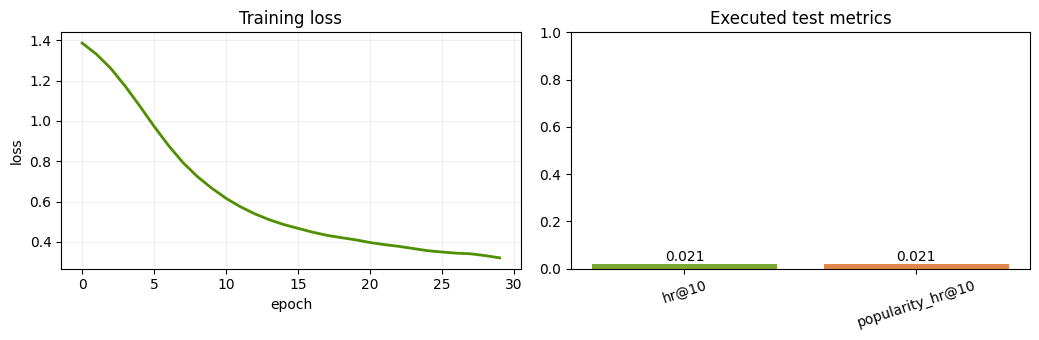

,value
hr@10,0.020833
popularity_hr@10,0.020833


In [5]:
fig,axes=plt.subplots(1,2,figsize=(10.5,3.5))
axes[0].plot(result['loss_curve'],color='#4f8f00',lw=2); axes[0].set(title='Training loss',xlabel='epoch',ylabel='loss'); axes[0].grid(alpha=.2)
metrics={'hr@10': result['hr@10'], 'popularity_hr@10': result['popularity_hr@10']}
axes[1].bar(range(len(metrics)),list(metrics.values()),color=['#7ca832','#e1874b','#6d88a4'][:len(metrics)])
axes[1].set_xticks(range(len(metrics)),list(metrics),rotation=18); axes[1].set(title='Executed test metrics',ylim=(0,max(1.0,max(metrics.values())*1.15)))
for index,value in enumerate(metrics.values()): axes[1].text(index,value,f'{value:.3f}',ha='center',va='bottom')
plt.tight_layout(); plt.show(); display(pd.Series(metrics,name='value').to_frame())

## Test & Results Discussion

In [6]:
display(Markdown(f'''### 本次已执行结果

- 主指标 hr@10 = **{result['hr@10']:.4f}**。
- 辅助指标 popularity_hr@10 = **{result['popularity_hr@10']:.4f}**。
- 本节没有把不同任务的数值伪装成 baseline；章节总结只做同口径比较。
- 训练损失从 **{result['loss_curve'][0]:.4f}** 降到 **{result['loss_curve'][-1]:.4f}**。损失下降只说明优化工作，不等于泛化或业务收益。
- **结果解释：** MovieLens 子集较小，SASRec 未必超过热门基线；本结果用于验证真实数据、严格时间切分和 Transformer 链路，而不是声称工业收益。

### 工业边界

截取最近 L 个真实行为 → 因果 Transformer → 最后位置用户向量 → 全库点积/ANN Top-K；屏蔽已见物品并监控序列截断与 P99。

上线前还需验证延迟、吞吐、内存/显存、数据新鲜度、校准、回滚和线上 A/B。
'''))

### 本次已执行结果

- 主指标 hr@10 = **0.0208**。
- 辅助指标 popularity_hr@10 = **0.0208**。
- 本节没有把不同任务的数值伪装成 baseline；章节总结只做同口径比较。
- 训练损失从 **1.3863** 降到 **0.3214**。损失下降只说明优化工作，不等于泛化或业务收益。
- **结果解释：** MovieLens 子集较小，SASRec 未必超过热门基线；本结果用于验证真实数据、严格时间切分和 Transformer 链路，而不是声称工业收益。

### 工业边界

截取最近 L 个真实行为 → 因果 Transformer → 最后位置用户向量 → 全库点积/ANN Top-K；屏蔽已见物品并监控序列截断与 P99。

上线前还需验证延迟、吞吐、内存/显存、数据新鲜度、校准、回滚和线上 A/B。


In [7]:
record={
    'algorithm': 'SASRec 自注意力序列推荐',
    'primary_metric': 'hr@10', 'primary_value': float(result['hr@10']),
    'secondary_metric': 'popularity_hr@10', 'secondary_value': float(result['popularity_hr@10']),
    'baseline_metric': None,
    'baseline_value': float(result[None]) if False else None,
    'framework': result['framework'], 'source_notebook': '3_5_1_sasrec',
    'dataset': 'MovieLens latest-small',
    'randomly_fabricated_rows': int(result['dataset']['randomly_fabricated_rows'])
}
path=save_records('chapter_3_5','3_5_1_sasrec',[record]); print('saved:',path.relative_to(ROOT))

saved: results/chapter_3_5/3_5_1_sasrec.json


## Checks

自动断言用于防止数据、训练和指标链路静默失效，不是效果证明。

In [8]:
assert result['loss_curve'][-1] < result['loss_curve'][0]
assert 0 <= float(result['hr@10']) <= 1
assert np.isfinite(float(result['popularity_hr@10']))
print('PASS：数据、训练、推理、测试和结果产物均已验证。')

PASS：数据、训练、推理、测试和结果产物均已验证。


## Next Steps

1. 换成对应公开数据的完整时间切分；2. 增加强 baseline 与消融；3. 记录效果、延迟和成本；4. 映射到 TorchEasyRec/官方 full profile；5. 只在相同候选与数据口径下比较。